# Dự đoán giá nhà ở Hà Nội 



1. Cài/nhập thư viện.
2. Tải dataset Hugging Face `tinixai/vietnam-real-estates`.
3. Lọc `province_name = "Hà Nội"`.
4. Làm sạch dữ liệu và tạo đặc trưng.
5. Train nhiều mô hình ML:
   - Ridge Regression + OneHotEncoder
   - Random Forest
   - HistGradientBoosting
   - Stacking Ensemble
6. Chọn mô hình tốt nhất theo RMSE.
7. Lưu model, metrics, model card.
8. Tạo FastAPI để dự đoán giá nhà.

Nếu chạy lần đầu trên máy yếu, đặt `MAX_ROWS = 20000` hoặc `30000`. Khi cần kết quả tốt hơn, tăng lên `80000`, `250000` hoặc nhiều hơn.

In [1]:

#%pip install -q fastapi "uvicorn[standard]" pydantic scikit-learn pandas numpy joblib datasets pyarrow PyYAML matplotlib nest_asyncio

## 1. Imports và cấu hình chung

In [2]:
from __future__ import annotations

import json
import os
from datetime import datetime, timezone
from functools import lru_cache
from pathlib import Path
from typing import Any, Optional

import joblib
import numpy as np
import pandas as pd

from datasets import load_dataset
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

CONFIG = {
    "dataset_id": "tinixai/vietnam-real-estates",
    "split": "train",
    "province": "Hà Nội",
    "streaming": False,
    "random_state": 42,
    "test_size": 0.2,
    "validation_metric": "rmse",
    "model_output_path": "models/hanoi_house_price_model.joblib",
    "metrics_output_path": "models/metrics.json",
    "model_card_path": "models/model_card.md",
    "filters": {
        "min_price_vnd": 100_000_000,
        "max_price_vnd": 200_000_000_000,
        "min_area_m2": 10,
        "max_area_m2": 1000,
    },
    "features": {
        "numeric": [
            "area",
            "area_log",
            "floor_count",
            "frontage_width",
            "house_depth",
            "road_width",
            "bedroom_count",
            "bathroom_count",
            "is_project_known",
            "published_year",
            "published_month",
        ],
        "categorical": [
            "property_type_name",
            "district_name",
            "ward_name",
            "street_name",
            "project_name",
            "house_direction",
            "balcony_direction",
        ],
    },
}

# Số dòng Hà Nội tối đa sẽ lấy từ Hugging Face.
# Tăng số này để train tốt hơn; giảm số này để chạy nhanh hơn.
MAX_ROWS = 80_000

# Có thể giảm danh sách model nếu máy yếu, ví dụ chỉ train ["ridge_onehot", "hist_gradient_boosting"].
MODELS_TO_TRAIN = [
    "ridge_onehot",
    "random_forest",
    "hist_gradient_boosting",
    "stacking_ensemble",
]

Path("models").mkdir(exist_ok=True)

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Tải dataset Hugging Face và lọc Hà Nội

In [3]:
REQUIRED_COLUMNS = [
    "property_type_name",
    "province_name",
    "district_name",
    "ward_name",
    "street_name",
    "project_name",
    "price",
    "area",
    "floor_count",
    "frontage_width",
    "house_depth",
    "road_width",
    "bedroom_count",
    "bathroom_count",
    "house_direction",
    "balcony_direction",
    "published_at",
]


def iter_hanoi_rows(records, province: str = "Hà Nội", max_rows: int | None = None) -> list[dict[str, Any]]:
    """Duyệt streaming dataset và chỉ giữ các dòng thuộc province mong muốn."""
    rows = []
    for row in records:
        if row.get("province_name") != province:
            continue

        rows.append({col: row.get(col) for col in REQUIRED_COLUMNS})

        if max_rows is not None and len(rows) >= max_rows:
            break

    return rows


def load_hanoi_dataset(
    dataset_id: str,
    split: str = "train",
    province: str = "Hà Nội",
    streaming: bool = True,
    max_rows: int | None = None,
) -> pd.DataFrame:
    """Tải dataset từ Hugging Face, lọc province_name = Hà Nội."""
    if streaming:
        ds = load_dataset(dataset_id, split=split, streaming=True)
        rows = iter_hanoi_rows(ds, province=province, max_rows=max_rows)
        df = pd.DataFrame(rows)
    else:
        ds = load_dataset(dataset_id, split=split)
        df = ds.to_pandas()
        df = df.loc[df["province_name"].eq(province), REQUIRED_COLUMNS]
        if max_rows is not None:
            df = df.head(max_rows)

    if df.empty:
        raise ValueError(
            f"Không tìm thấy dòng nào với province={province!r}. "
            "Hãy kiểm tra dataset_id, split hoặc cách viết tên tỉnh/thành."
        )

    return df.reset_index(drop=True)


raw_df = load_hanoi_dataset(
    dataset_id=CONFIG["dataset_id"],
    split=CONFIG["split"],
    province=CONFIG["province"],
    streaming=CONFIG["streaming"],
    max_rows=MAX_ROWS,
)

print(f"Số dòng Hà Nội tải được: {len(raw_df):,}")
raw_df.head()
#lưu dataset
raw_df.to_csv("hanoi_real_estate.csv", index=False)

Số dòng Hà Nội tải được: 80,000


## 3. Làm sạch dữ liệu và tạo đặc trưng

In [4]:
def clean_training_data(df: pd.DataFrame, filters: dict[str, Any]) -> pd.DataFrame:
    """Làm sạch dữ liệu train: ép kiểu số, lọc giá/diện tích bất thường, xử lý categorical rỗng."""
    df = df.copy()

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["area"] = pd.to_numeric(df["area"], errors="coerce")

    mask = (
        df["price"].between(filters["min_price_vnd"], filters["max_price_vnd"], inclusive="both")
        & df["area"].between(filters["min_area_m2"], filters["max_area_m2"], inclusive="both")
    )
    df = df.loc[mask].copy()

    numeric_cols = [
        "floor_count",
        "frontage_width",
        "house_depth",
        "road_width",
        "bedroom_count",
        "bathroom_count",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    categorical_cols = [
        "property_type_name",
        "district_name",
        "ward_name",
        "street_name",
        "project_name",
        "house_direction",
        "balcony_direction",
    ]
    for col in categorical_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .fillna("Unknown")
                .astype(str)
                .str.strip()
                .replace("", "Unknown")
            )

    if df.empty:
        raise ValueError("Tất cả dòng bị loại trong bước cleaning. Hãy nới filter hoặc kiểm tra dữ liệu.")

    return df.reset_index(drop=True)


def engineer_features_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo đặc trưng dùng chung cho train và inference.

    Function này không dùng target `price`, nên an toàn cho validation và API.
    """
    X = df.copy()

    if "published_at" in X.columns:
        published = pd.to_datetime(X["published_at"], errors="coerce", utc=True)
        X["published_year"] = published.dt.year.fillna(0).astype(int)
        X["published_month"] = published.dt.month.fillna(0).astype(int)
    else:
        X["published_year"] = 0
        X["published_month"] = 0

    X["area"] = pd.to_numeric(X.get("area"), errors="coerce")
    X["area_log"] = np.log1p(X["area"].clip(lower=0))

    project = X.get("project_name", pd.Series([""] * len(X)))
    project = project.fillna("").astype(str).str.strip()
    X["is_project_known"] = np.where(project.ne("") & project.ne("Unknown"), 1, 0)

    # Các cột này không đưa trực tiếp vào mô hình.
    X = X.drop(columns=["province_name", "published_at"], errors="ignore")

    return X


df = clean_training_data(raw_df, CONFIG["filters"])
print(f"Số dòng sau cleaning: {len(df):,}")

display(df.head())
display(df[["price", "area"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

Số dòng sau cleaning: 76,772


,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,Nhà,Hà Nội,Bắc Từ Liêm,Phúc Diễn,Ngọa Long,Unknown,7.450000e+09,37.0,NaN,NaN,NaN,NaN,4.0,5.0,Unknown,Unknown,2025-06-01T05:12:56.941000
1,Căn hộ chung cư,Hà Nội,Tây Hồ,Unknown,Unknown,Sunshine Riverside,7.400000e+09,90.0,NaN,NaN,NaN,NaN,3.0,2.0,Đông,Unknown,2025-06-04T11:26:05.659000
2,Nhà,Hà Nội,Cầu Giấy,Nghĩa Tân,Hoàng Quốc Việt,Unknown,1.670000e+10,41.0,NaN,4.1,NaN,NaN,4.0,3.0,Unknown,Unknown,2025-06-23T02:19:27.548000
3,Đất,Hà Nội,Quốc Oai,Hòa Thạch,Unknown,Unknown,2.860000e+09,220.0,NaN,9.0,NaN,4.0,NaN,NaN,Unknown,Unknown,2025-06-04T00:21:59.750000
4,Nhà,Hà Nội,Nam Từ Liêm,Mỹ Đình 2,Lê Đức Thọ,Unknown,8.900000e+09,42.0,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,2025-06-27T07:48:43.661000


,price,area
count,7.677200e+04,76772.000000
mean,1.546134e+10,79.074882
std,1.968889e+10,63.642187
min,1.000000e+08,10.000000
1%,1.650000e+09,25.000000
5%,2.800000e+09,31.000000
50%,9.000000e+09,62.300000
95%,5.000000e+10,181.000000
99%,1.100000e+11,340.000000
max,2.000000e+11,1000.000000


## 4. Chia train/validation

In [5]:
X_raw = df.drop(columns=["price"])
y = df["price"].astype(float)

X = engineer_features_frame(X_raw)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
)

print(f"Train rows: {len(X_train):,}")
print(f"Valid rows: {len(X_valid):,}")
X_train.head()

Train rows: 61,417
Valid rows: 15,355


,property_type_name,district_name,ward_name,street_name,project_name,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_year,published_month,area_log,is_project_known
65378,Đất,Bắc Từ Liêm,Thụy Phương,Unknown,Unknown,76.2,NaN,NaN,NaN,NaN,NaN,NaN,Đông Nam,Unknown,2025,6,4.346399,0
30092,Đất,Gia Lâm,Bát Tràng,379,Unknown,45.0,NaN,4.0,NaN,NaN,NaN,NaN,Đông Bắc,Unknown,2025,6,3.828641,0
38866,Nhà,Long Biên,Ngọc Lâm,Nguyễn Văn Cừ,Unknown,65.0,7.0,4.0,NaN,6.0,4.0,6.0,Unknown,Unknown,2025,6,4.189655,0
75692,Căn hộ chung cư,Đống Đa,Phương Mai,Trường Chinh,Capital Garden 102 Trường Chinh,91.0,NaN,NaN,NaN,NaN,2.0,2.0,Unknown,Unknown,2025,6,4.521789,1
34795,Căn hộ chung cư,Hà Đông,La Khê,Tố Hữu,The Pride,88.0,NaN,NaN,NaN,NaN,2.0,2.0,Unknown,Unknown,2025,6,4.488636,1


## 5. Xây dựng các mô hình ML

In [6]:
def make_one_hot_encoder():
    """Tạo OneHotEncoder tương thích nhiều phiên bản scikit-learn."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse=True,
        )


def build_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
    categorical_mode: str,
) -> ColumnTransformer:
    """Tạo preprocessing pipeline cho numeric và categorical columns."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    if categorical_mode == "onehot":
        categorical_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("encoder", make_one_hot_encoder()),
            ]
        )
    elif categorical_mode == "ordinal":
        categorical_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                        encoded_missing_value=-1,
                    ),
                ),
            ]
        )
    else:
        raise ValueError(f"categorical_mode không hợp lệ: {categorical_mode!r}")

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_base_pipeline(
    numeric_features: list[str],
    categorical_features: list[str],
    estimator,
    categorical_mode: str,
) -> Pipeline:
    """Pipeline chỉ chứa sklearn built-in transformers/models để model lưu ra dễ load trong FastAPI."""
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_features, categorical_features, categorical_mode)),
            ("model", estimator),
        ]
    )


def with_log_target(regressor) -> TransformedTargetRegressor:
    """Train trên log1p(price), predict tự chuyển về VND bằng expm1."""
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def build_models(features: dict, random_state: int = 42) -> dict[str, TransformedTargetRegressor]:
    """Tạo các model candidate.

    Ý tưởng kết hợp:
    - Ridge + OneHot: baseline tuyến tính, ổn định.
    - RandomForest: bắt quan hệ phi tuyến, ít cần tuning.
    - HistGradientBoosting: mạnh với dữ liệu tabular lớn.
    - Stacking: kết hợp dự báo từ nhiều hướng học khác nhau.
    """
    numeric = features["numeric"]
    categorical = features["categorical"]

    ridge = make_base_pipeline(
        numeric,
        categorical,
        Ridge(alpha=5.0, random_state=random_state),
        categorical_mode="onehot",
    )

    random_forest = make_base_pipeline(
        numeric,
        categorical,
        RandomForestRegressor(
            n_estimators=250,
            max_depth=24,
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=random_state,
        ),
        categorical_mode="ordinal",
    )

    hist_gbr = make_base_pipeline(
        numeric,
        categorical,
        HistGradientBoostingRegressor(
            learning_rate=0.06,
            max_iter=350,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=random_state,
        ),
        categorical_mode="ordinal",
    )

    stacking_estimators = [
        (
            "ridge_onehot",
            make_base_pipeline(
                numeric,
                categorical,
                Ridge(alpha=5.0, random_state=random_state),
                categorical_mode="onehot",
            ),
        ),
        (
            "rf_ordinal",
            make_base_pipeline(
                numeric,
                categorical,
                RandomForestRegressor(
                    n_estimators=120,
                    max_depth=20,
                    min_samples_leaf=4,
                    n_jobs=-1,
                    random_state=random_state,
                ),
                categorical_mode="ordinal",
            ),
        ),
        (
            "hgb_ordinal",
            make_base_pipeline(
                numeric,
                categorical,
                HistGradientBoostingRegressor(
                    learning_rate=0.07,
                    max_iter=220,
                    max_leaf_nodes=31,
                    l2_regularization=0.05,
                    random_state=random_state,
                ),
                categorical_mode="ordinal",
            ),
        ),
    ]

    stacking = StackingRegressor(
        estimators=stacking_estimators,
        final_estimator=RidgeCV(alphas=(0.1, 1.0, 10.0)),
        cv=3,
        n_jobs=-1,
        passthrough=False,
    )

    return {
        "ridge_onehot": with_log_target(ridge),
        "random_forest": with_log_target(random_forest),
        "hist_gradient_boosting": with_log_target(hist_gbr),
        "stacking_ensemble": with_log_target(stacking),
    }


def evaluate_regression(y_true, y_pred) -> dict[str, float]:
    """Tính metric regression trên đơn vị VND gốc."""
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, a_min=0, a_max=None)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    denom = np.maximum(np.asarray(y_true, dtype=float), 1.0)
    mape = float(np.mean(np.abs((np.asarray(y_true) - y_pred) / denom)) * 100)

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mape_percent": mape,
    }


all_models = build_models(CONFIG["features"], random_state=CONFIG["random_state"])
print("Available models:", list(all_models.keys()))

Available models: ['ridge_onehot', 'random_forest', 'hist_gradient_boosting', 'stacking_ensemble']


## 6. Train, evaluate và chọn model tốt nhất

In [7]:
metrics: dict[str, dict] = {}
fitted_models: dict[str, Any] = {}

for name in MODELS_TO_TRAIN:
    if name not in all_models:
        raise ValueError(f"Model không tồn tại: {name}")

    print(f"\nTraining {name}...")
    model = all_models[name]

    try:
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        model_metrics = evaluate_regression(y_valid, pred)

        metrics[name] = model_metrics
        fitted_models[name] = model

        print(
            f"{name}: "
            f"RMSE={model_metrics['rmse']:,.0f} | "
            f"MAE={model_metrics['mae']:,.0f} | "
            f"R2={model_metrics['r2']:.4f} | "
            f"MAPE={model_metrics['mape_percent']:.2f}%"
        )
    except Exception as exc:
        metrics[name] = {"error": repr(exc)}
        print(f"{name} failed: {exc!r}")

if not fitted_models:
    raise RuntimeError("Không có model nào train thành công.")

metric_name = CONFIG["validation_metric"]
best_name = min(fitted_models, key=lambda n: metrics[n][metric_name])
best_model = fitted_models[best_name]

print(f"\nModel tốt nhất: {best_name} theo {metric_name}")

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)


Training ridge_onehot...
ridge_onehot: RMSE=9,702,268,773 | MAE=4,052,563,094 | R2=0.7524 | MAPE=36.17%

Training random_forest...
random_forest: RMSE=8,867,446,241 | MAE=3,528,030,656 | R2=0.7932 | MAPE=32.51%

Training hist_gradient_boosting...


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

hist_gradient_boosting: RMSE=8,875,163,832 | MAE=3,886,574,619 | R2=0.7929 | MAPE=34.27%

Training stacking_ensemble...
stacking_ensemble: RMSE=8,597,938,857 | MAE=3,721,377,205 | R2=0.8056 | MAPE=33.42%

Model tốt nhất: stacking_ensemble theo rmse


,rmse,mae,r2,mape_percent
ridge_onehot,9.702269e+09,4.052563e+09,0.752450,36.171680
random_forest,8.867446e+09,3.528031e+09,0.793217,32.508021
hist_gradient_boosting,8.875164e+09,3.886575e+09,0.792857,34.267132
stacking_ensemble,8.597939e+09,3.721377e+09,0.805596,33.424181


## 7. Visualization nhanh kết quả validation

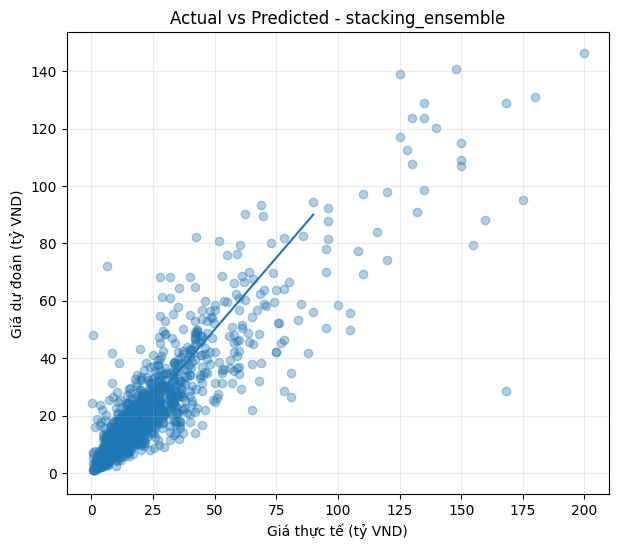

In [8]:
valid_pred = best_model.predict(X_valid)
plot_df = pd.DataFrame({
    "actual_price_billion_vnd": y_valid.values / 1_000_000_000,
    "predicted_price_billion_vnd": valid_pred / 1_000_000_000,
})

sample_plot_df = plot_df.sample(min(3000, len(plot_df)), random_state=CONFIG["random_state"])

plt.figure(figsize=(7, 6))
plt.scatter(
    sample_plot_df["actual_price_billion_vnd"],
    sample_plot_df["predicted_price_billion_vnd"],
    alpha=0.35,
)
max_val = float(np.nanpercentile(sample_plot_df[["actual_price_billion_vnd", "predicted_price_billion_vnd"]], 99))
plt.plot([0, max_val], [0, max_val])
plt.xlabel("Giá thực tế (tỷ VND)")
plt.ylabel("Giá dự đoán (tỷ VND)")
plt.title(f"Actual vs Predicted - {best_name}")
plt.grid(True, alpha=0.25)
plt.show()

## 8. Lưu model, metrics và model card

In [9]:
def write_model_card(
    path: str | Path,
    selected_model: str,
    metrics: dict,
    config: dict,
    n_train: int,
    n_valid: int,
) -> None:
    """Ghi model card dạng markdown."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = [
        "# Hanoi House Price Model Card",
        "",
        f"Generated at: {datetime.now(timezone.utc).isoformat()}",
        f"Dataset: `{config['dataset_id']}`",
        f"Province filter: `{config.get('province', 'Hà Nội')}`",
        f"Selected model: `{selected_model}`",
        f"Train rows: {n_train:,}",
        f"Validation rows: {n_valid:,}",
        "",
        "## Validation metrics",
        "",
        "| Model | RMSE | MAE | R2 | MAPE % |",
        "|---|---:|---:|---:|---:|",
    ]

    for name, values in metrics.items():
        if "error" in values:
            lines.append(f"| {name} | error | error | error | error |")
            continue

        lines.append(
            f"| {name} | {values['rmse']:,.0f} | {values['mae']:,.0f} | "
            f"{values['r2']:.4f} | {values['mape_percent']:.2f} |"
        )

    lines.extend(
        [
            "",
            "## Notes",
            "",
            "- Target `price` được train qua log1p/expm1 để giảm ảnh hưởng outlier.",
            "- Metrics báo cáo theo đơn vị VND gốc.",
            "- Model artifact không chứa custom sklearn transformer, giúp load dễ hơn trong FastAPI.",
        ]
    )

    path.write_text("\n".join(lines), encoding="utf-8")


artifact = {
    "model": best_model,
    "selected_model": best_name,
    "metrics": metrics,
    "features": CONFIG["features"],
    "required_columns": REQUIRED_COLUMNS,
    "dataset_id": CONFIG["dataset_id"],
    "province": CONFIG["province"],
    "created_at": datetime.now(timezone.utc).isoformat(),
    "model_version": "hanoi-house-price-regressor",
}

model_output_path = Path(CONFIG["model_output_path"])
metrics_output_path = Path(CONFIG["metrics_output_path"])
model_card_path = Path(CONFIG["model_card_path"])

model_output_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(artifact, model_output_path)
metrics_output_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
write_model_card(model_card_path, best_name, metrics, CONFIG, len(X_train), len(X_valid))

print(f"Saved model: {model_output_path}")
print(f"Saved metrics: {metrics_output_path}")
print(f"Saved model card: {model_card_path}")

Saved model: models\hanoi_house_price_model.joblib
Saved metrics: models\metrics.json
Saved model card: models\model_card.md


## 9. Hàm dự đoán local trong notebook

In [ ]:
RAW_MODEL_COLUMNS = [
    "property_type_name",
    "province_name",
    "district_name",
    "ward_name",
    "street_name",
    "project_name",
    "area",
    "floor_count",
    "frontage_width",
    "house_depth",
    "road_width",
    "bedroom_count",
    "bathroom_count",
    "house_direction",
    "balcony_direction",
    "published_at",
]


def load_model_artifact(model_path: str | Path = CONFIG["model_output_path"]) -> dict[str, Any]:
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Không thấy model tại {model_path}. Hãy chạy cell train/lưu model trước.")

    loaded_artifact = joblib.load(model_path)
    if not isinstance(loaded_artifact, dict) or "model" not in loaded_artifact:
        raise ValueError(f"Model artifact không hợp lệ: {model_path}")

    return loaded_artifact


def make_prediction_frame(payload: dict[str, Any]) -> pd.DataFrame:
    row = {col: payload.get(col) for col in RAW_MODEL_COLUMNS}
    row["province_name"] = row.get("province_name") or "Hà Nội"
    row["project_name"] = row.get("project_name") or "Unknown"
    row["published_at"] = row.get("published_at") or None

    return pd.DataFrame([row], columns=RAW_MODEL_COLUMNS)


def predict_price_vnd(loaded_artifact: dict[str, Any], payload: dict[str, Any]) -> float:
    model = loaded_artifact["model"]

    raw_input = make_prediction_frame(payload)
    X_input = engineer_features_frame(raw_input)

    pred = float(model.predict(X_input)[0])

    if not np.isfinite(pred):
        raise ValueError("Model trả về giá trị không hợp lệ.")

    return max(pred, 0.0)


sample_payload = {
    "property_type_name": "Căn hộ chung cư",
    "district_name": "Cầu Giấy",
    "ward_name": "Dịch Vọng",
    "street_name": "Xuân Thủy",
    "project_name": "",
    "area": 75,
    "floor_count": 1,
    "frontage_width": None,
    "house_depth": None,
    "road_width": 12,
    "bedroom_count": 2,
    "bathroom_count": 2,
    "house_direction": "Đông Nam",
    "balcony_direction": "Đông Nam",
    "published_at": "2026-03-15T00:00:00Z",
}

loaded_artifact = load_model_artifact()
price = predict_price_vnd(loaded_artifact, sample_payload)

print(f"Selected model: {loaded_artifact['selected_model']}")
print(f"Predicted price: {price:,.0f} VND")
print(f"Predicted price: {price / 1_000_000_000:.3f} tỷ VND")

Selected model: stacking_ensemble
Predicted price: 6,082,374,677 VND
Predicted price: 6.082 tỷ VND
